In [1]:
import sys
import os
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

from generator.instance_generator import ShuntingYard
from generator.option_enums import CostOption, LengthOption, LocationOption, Goal, Direction, CrewOption, MovementOption, SwitchOption, TurnOption

import networkx as nx

/home/nlonyuk/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
walking_distances = {
    ("51b", "entry"):8,
    ("51b", "52"):4,
    ("51b", "53"):3,
    ("51b", "54"):4,
    ("51b", "55"):5,
    ("51b", "56"):6,
    ("51b", "57"):7,
    ("51b", "58"):8,
    ("51b", "59"):9,
    ("51b", "60"):2,
    ("51b", "61_service"):3,
    ("51b", "62_service"):4,
    ("51b", "63"):6,
    ("entry", "52"):3,
    ("entry", "53"):4,
    ("entry", "54"):5,
    ("entry", "55"):6,
    ("entry", "56"):7,
    ("entry", "57"):8,
    ("entry", "58"):9,
    ("entry", "59"):10,
    ("entry", "60"):8,
    ("entry", "61_service"):9,
    ("entry", "62_service"):10,
    ("entry", "63"):12,
    ("52", "53"):1,
    ("52", "54"):2,
    ("52", "55"):3,
    ("52", "56"):4,
    ("52", "57"):5,
    ("52", "58"):6,
    ("52", "59"):7,
    ("52", "60"):5,
    ("52", "61_service"):6,
    ("52", "62_service"):7,
    ("52", "63"):10,
    ("53", "54"):1,
    ("53", "55"):2,
    ("53", "56"):3,
    ("53", "57"):4,
    ("53", "58"):5,
    ("53", "59"):6,
    ("53", "60"):4,
    ("53", "61_service"):5,
    ("53", "62_service"):6,
    ("53", "63"):9,
    ("54", "55"):1,
    ("54", "56"):2,
    ("54", "57"):3,
    ("54", "58"):4,
    ("54", "59"):5,
    ("54", "60"):3,
    ("54", "61_service"):4,
    ("54", "62_service"):5,
    ("54", "63"):8,
    ("55", "56"):1,
    ("55", "57"):2,
    ("55", "58"):3,
    ("55", "59"):4,
    ("55", "60"):4,
    ("55", "61_service"):3,
    ("55", "62_service"):4,
    ("55", "63"):7,
    ("56", "57"):1,
    ("56", "58"):2,
    ("56", "59"):3,
    ("56", "60"):5,
    ("56", "61_service"):4,
    ("56", "62_service"):3,
    ("56", "63"):6,
    ("57", "58"):1,
    ("57", "59"):2,
    ("57", "60"):6,
    ("57", "61_service"):5,
    ("57", "62_service"):4,
    ("57", "63"):7,
    ("58", "59"):1,
    ("58", "60"):7,
    ("58", "61_service"):6,
    ("58", "62_service"):5,
    ("58", "63"):8,
    ("59", "60"):8,
    ("59", "61_service"):7,
    ("59", "62_service"):6,
    ("59", "63"):9,
    ("60", "61_service"):1,
    ("60", "62_service"):2,
    ("60", "63"):4,
    ("61_service", "62_service"):1,
    ("61_service", "63"):3,
    ("62_service", "63"):4,
}

In [3]:
for num_t in range(3,21):
    yard = ShuntingYard(
        cost_option=CostOption.METRIC,
        crew_option=CrewOption.NONE,
        movement_option=MovementOption.ACROSS,
        turn_option=TurnOption.NONE,
        walking_durations=None,
        switch_option=SwitchOption.NONE,
        unique_entry_distance=False,
        goal_actions=True,
        negative_preconditions=True,
        domain_name="dom_1a",
        problem_name=f"bh_1_{num_t}t",
    )

    yard.load_location_json("data/yard_jsons/location_kleine_binckhorst.json")
    yard.remove_tracks(["64", "906c", "104a", "51b"])
    yard.make_entry_track("906a")
    # yard.add_entry_track(["52", "53", "54", "55", "56", "57", "58", "59"], Direction.BSIDE)
    yard.set_service_tracks(["61", "62"])
    yard.load_train_json(f"data/train_jsons/{num_t}trains.json")
    yard.set_all_goals([Goal.AHEAD])
    yard.add_drivers(["Andy"])
    yard.simplify_track_lengths()

    for tr in ["51b", "entry", "Phantom1"]:
        track = yard.get_track(tr)
        if track is not None:
            track.max_trains = 0

    yard.generate()

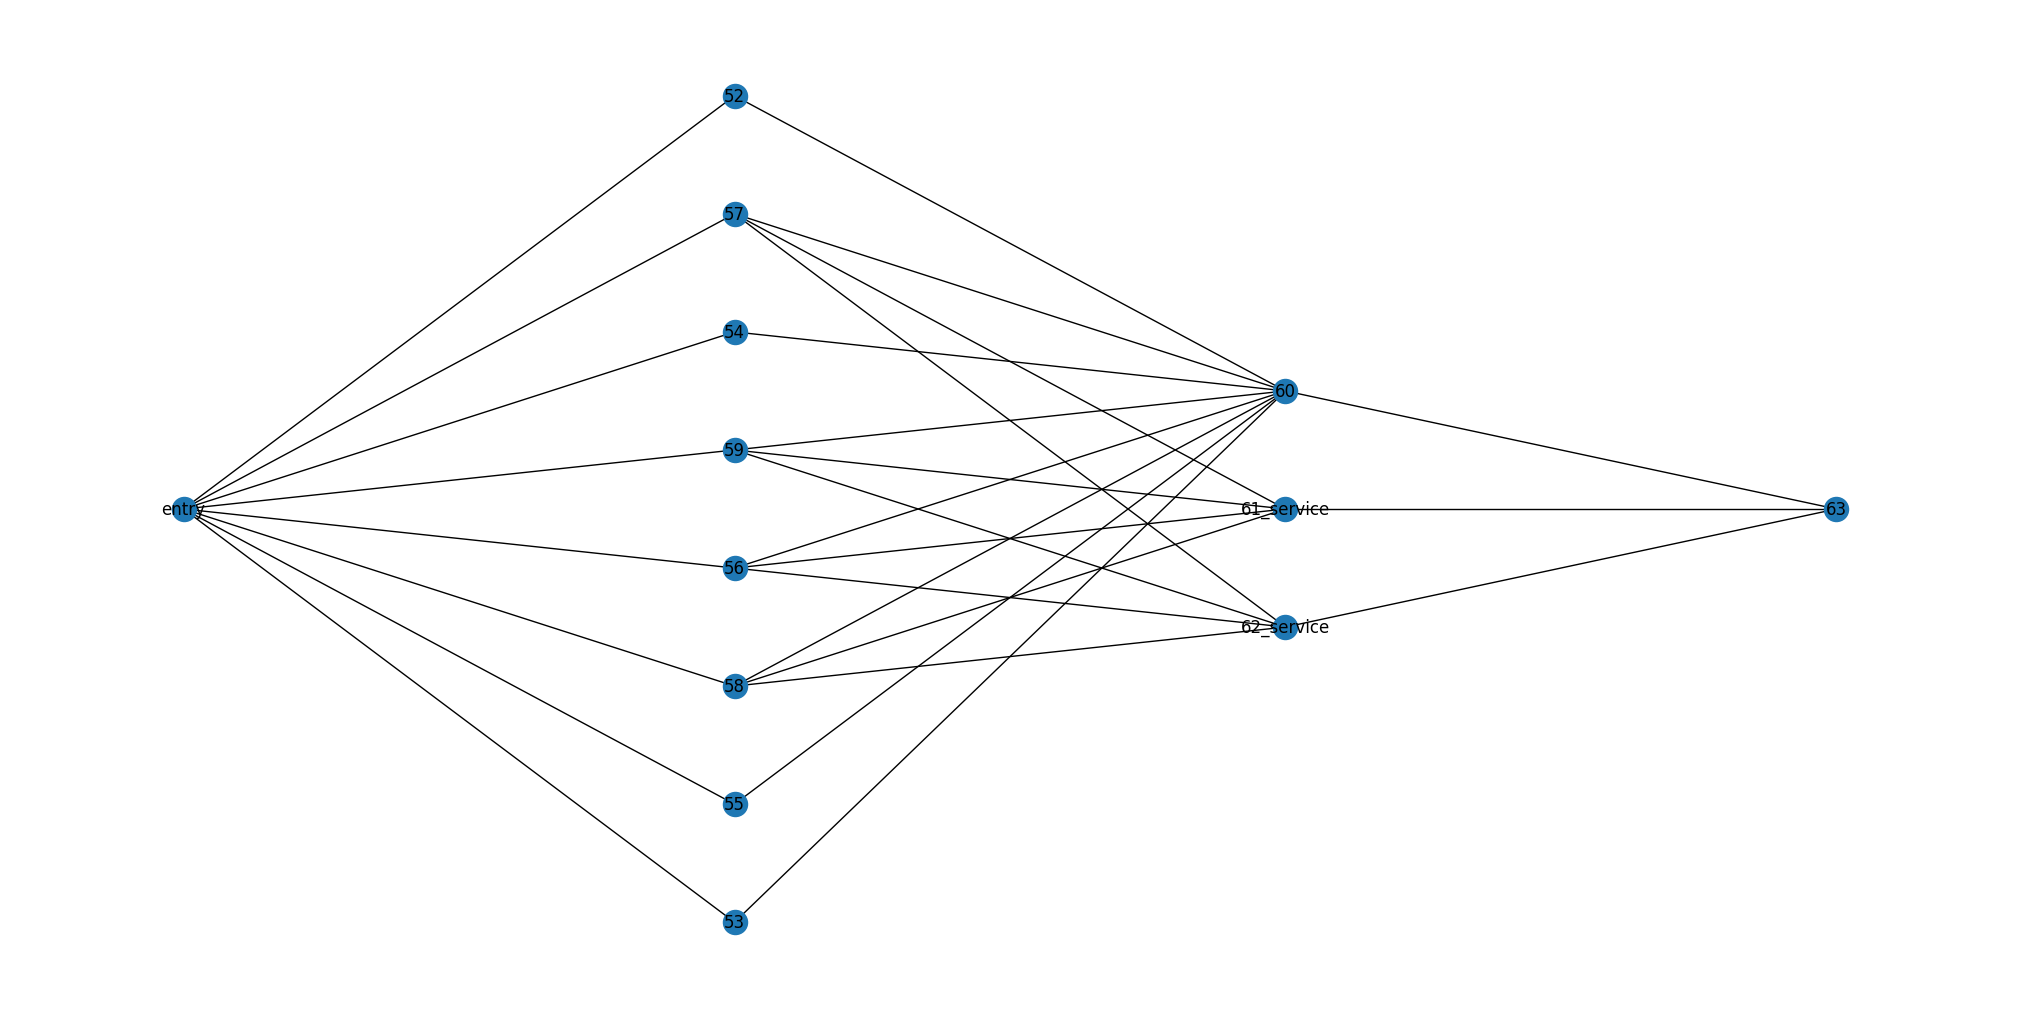

In [4]:
yard.visualize()